<a href="https://colab.research.google.com/github/narendra2006/Pipeline_Silent_Face_Anti-Spoofing/blob/main/pipeline_Silent_Face_Anti_Spoofing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Step 0: Environment Setup**


---


Tahap inisialisasi workspace, tujuannya mengaitkan Google Drive sebagai sumber dataset, menginstal dependensi yang dibutuhkan, mengunduh repository
Silent Face Anti-Spoofing, dan menyiapkan YuNet dan SCRFD sebagai face detector
utama yang tahan dan kompatibel untuk deployment mobile via ONNX.

In [ ]:
# Menghubungkan Google Drive sebagai sumber dataset dan penyimpanan model.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Mengunci semua sumber keacakan agar hasil training konsisten.
import os, torch, random, numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Benchmark dinyalakan untuk speed, deterministic dimatikan
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print(f"Random seed terkunci: {SEED} (cuDNN Benchmark: ON)")

Random seed terkunci: 42 (cuDNN Benchmark: ON)


In [ ]:
# Mengatur TRESHOLD
THRESHOLD = 0.75

In [ ]:
# Install InsightFace
!pip install -q insightface

# Menghapus onnx versi CPU
!pip uninstall -y onnxruntime

# Install onnx versi GPU, opencv, easydict dan tensorboardx
!pip install -q onnxruntime-gpu opencv-python easydict tensorboardX onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 96.1 MB/s eta 0:00:00
Found existing installation: onnxruntime 1.27.0
Uninstalling onnxruntime-1.27.0:
  Successfully uninstalled onnxruntime-1.27.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.5 MB/s eta 0:00:00


In [ ]:
import os
import insightface
import urllib.request
from insightface.app import FaceAnalysis

%cd /content

# Clone Repository Silent-Face-Anti-Spoofing
!rm -rf /content/Silent-Face-Anti-Spoofing
!git clone -q https://github.com/narendra2006/Silent-Face-Anti-Spoofing.git

# Mengunduh model YuNet (Detector Utama)
YUNET_PATH = '/content/Silent-Face-Anti-Spoofing/src/yunet.onnx'
YUNET_URL  = (
    'https://github.com/opencv/opencv_zoo/raw/main/'
    'models/face_detection_yunet/face_detection_yunet_2023mar.onnx'
)

if not os.path.exists(YUNET_PATH):
    print(" → Mendownload YuNet (0.23MB)...")
    try:
        # Menggunakan urllib agar error bisa ditangkap
        urllib.request.urlretrieve(YUNET_URL, YUNET_PATH)
        print(" YuNet berhasil diunduh!")
    except Exception as e:
        # Jika gagal, akan masuk ke sini
        print(f" Gagal mendownload YuNet! Error: {e}")
        raise SystemExit("Proses dihentikan karena model utama gagal diunduh.") # Menghentikan eksekusi

# Mengunduh & Inisialisasi model SCRFD (Detector Fallback)
print(" → Mendownload & inisialisasi SCRFD via InsightFace...")
scrfd_app = FaceAnalysis(name='buffalo_s', allowed_modules=['detection'], providers=['CUDAExecutionProvider'])
scrfd_app.prepare(ctx_id=0, det_size=(640, 640))

print(" → Semua model detektor berhasil diunduh dan diinisialisasi!")

/content
 → Mendownload YuNet (0.23MB)...
 YuNet berhasil diunduh!
 → Mendownload & inisialisasi SCRFD via InsightFace...
download_path: /root/.insightface/models/buffalo_s


100%|██████████| 124617/124617 [00:01<00:00, 99552.73KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: /root/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvid

In [ ]:
# Memastikan semua komponen yang dibutuhkan sudah siap
import cv2, torch, sys

print("=" * 60)
print(" VERIFIKASI ENVIRONMENT (YUNET + SCRFD)")
print("=" * 60)

# Library
print(f"  OpenCV        : {cv2.__version__}")
print(f"  PyTorch       : {torch.__version__}")
try:
    import insightface
    print(f"  InsightFace   : {insightface.__version__}")
except ImportError:
    print(f"  InsightFace   : Tidak terinstall")

# Hardware
gpu_info = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'
print(f"  GPU           : {gpu_info}")

# Repository Path Configuration
repo_path = '/content/Silent-Face-Anti-Spoofing'
repo_ok = os.path.exists(os.path.join(repo_path, 'src'))

if repo_ok:
    # Hanya masukkan ke sys.path JIKA reponya benar-benar ada
    if repo_path not in sys.path:
        sys.path.append(repo_path)
    print("  Repository    : Ada & masuk sys.path")
else:
    print("  Repository    : Tidak ada")

# Detektor YuNet
if os.path.exists(YUNET_PATH):
    ukuran_kb = os.path.getsize(YUNET_PATH) / 1024
    print(f"  YuNet (L1)    : Ada ({ukuran_kb:.1f} KB)")
else:
    print(f"  YuNet (L1)    : Tidak ada")

# ONNX Runtime (GPU Check)
try:
    import onnxruntime as ort
    providers = ort.get_available_providers()
    gpu_provider = 'CUDAExecutionProvider' in providers
    print(f"  ONNX Runtime  : {ort.__version__} (GPU: {gpu_provider})")
except ImportError:
    print(f"  ONNX Runtime  : Tidak terinstall")

print("=" * 60)

# Status keseluruhan
semua_ok = all([repo_ok, os.path.exists(YUNET_PATH), gpu_provider])

if semua_ok:
    print(" SEMUA KOMPONEN SIAP → Lanjut ke Step 1")
else:
    print(" Ada komponen yang belum siap (Pastikan pakai Runtime GPU T4!)")

 VERIFIKASI ENVIRONMENT (YUNET + SCRFD)
  OpenCV        : 4.13.0
  PyTorch       : 2.11.0+cu128
  InsightFace   : 1.0.1
  GPU           : Tesla T4
  Repository    : Ada & masuk sys.path
  YuNet (L1)    : Ada (227.1 KB)
  ONNX Runtime  : 1.26.0 (GPU: True)
 SEMUA KOMPONEN SIAP → Lanjut ke Step 1


## **Step 1.0: Data Collection**

---
Tahap pengumpulan dataset. Mengambil dataset wajah Asli (Live) dan Palsu (Spoof) dari Google Drive dalam format ZIP, mengekstraknya, lalu
menyusunnya ke dalam struktur folder yang rapi sebagai fondasi pipeline.

In [ ]:
from pathlib import Path
import os, glob, shutil, subprocess

# Direktori utama pipeline
INGESTION_DIR   = '/content/ml_pipeline/01_raw_data'
CLASS_ASLI_DIR  = os.path.join(INGESTION_DIR, 'class_1_asli')
CLASS_SPOOF_DIR = os.path.join(INGESTION_DIR, 'class_0_spoof')
TEMP_BUFFER     = '/content/temp_buffer'

# Lokasi file ZIP di Google Drive
ZIP_PATH_ASLI  = '/content/drive/MyDrive/Dataset Asli Final.zip'
ZIP_PATH_SPOOF = '/content/drive/MyDrive/Dataset Palsu Final.zip'

print(" Konfigurasi path selesai")
print(f" → Asli  : {ZIP_PATH_ASLI}")
print(f" → Spoof : {ZIP_PATH_SPOOF}")

 Konfigurasi path selesai
 → Asli  : /content/drive/MyDrive/Dataset Asli Final.zip
 → Spoof : /content/drive/MyDrive/Dataset Palsu Final.zip


In [ ]:
# Menghapus sisa data dari sesi sebelumnya
TARGET_FOLDERS = [CLASS_ASLI_DIR, CLASS_SPOOF_DIR, TEMP_BUFFER]

print(" Membersihkan folder lama yang masih tersisa")
for folder in TARGET_FOLDERS:
    shutil.rmtree(folder, ignore_errors=True)
    os.makedirs(folder, exist_ok=True)
    print(f" → {folder}")

print(" Semua folder bersih dan siap diisi")

 Membersihkan folder lama yang masih tersisa
 → /content/ml_pipeline/01_raw_data/class_1_asli
 → /content/ml_pipeline/01_raw_data/class_0_spoof
 → /content/temp_buffer
 Semua folder bersih dan siap diisi


In [ ]:
def ekstrak_dataset(zip_path: str, tujuan_dir: str, nama_kelas: str, temp_buffer: str = '/content/temp_buffer'):
    """
    Args:
        zip_path (str): Path sumber file ZIP.
        tujuan_dir (str): Path direktori tujuan untuk meletakkan hasil ekstraksi.
        nama_kelas (str): Label nama kelas/dataset untuk keperluan log.
        temp_buffer (str, optional): Direktori sementara untuk proses ekstraksi.
                                     Default: '/content/temp_buffer'.

    Returns:
        tuple: (jumlah_foto: int, kategori_list: list[str])
    """
    if not os.path.exists(zip_path):
        print(f" File ZIP tidak ditemukan: {zip_path}")
        return 0, []

    # OPTIMISASI I/O
    print(f" Menyalin {nama_kelas} dari Drive ke Colab...")
    local_zip_path = os.path.join('/content', os.path.basename(zip_path))

    try:
        # Menggunakan shutil.copy2
        shutil.copy2(zip_path, local_zip_path)

        # Ekstrak ke temp buffer
        print(f" Mengekstrak {nama_kelas}...")
        os.makedirs(temp_buffer, exist_ok=True)

        # Menggunakan subprocess.run untuk menangkap error saat unzip
        subprocess.run(['unzip', '-q', local_zip_path, '-d', temp_buffer], check=True)

    except subprocess.CalledProcessError as e:
        print(f" Gagal mengekstrak file ZIP! Detail: {e}")
        shutil.rmtree(temp_buffer, ignore_errors=True)
        return 0, []
    except Exception as e:
        print(f" Terjadi kesalahan sistem: {e}")
        return 0, []
    finally:
        # Hapus zip lokal agar tidak memakan memori Colab
        if os.path.exists(local_zip_path):
            os.remove(local_zip_path)

    # Cari semua file gambar
    semua_file      = glob.glob(os.path.join(temp_buffer, '**', '*.*'), recursive=True)
    jumlah_berhasil = 0
    jumlah_duplikat = 0
    kategori_found  = set()

    # Ekstrak nama folder temp untuk pencarian indeks dinamis
    nama_temp_folder = os.path.basename(temp_buffer).lower()

    for img_path in semua_file:
        if not img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
            continue

        bagian   = Path(img_path).parts
        temp_idx = next(
            (i for i, p in enumerate(bagian) if nama_temp_folder in p.lower()),
            None
        )
        if temp_idx is None:
            continue

        # Deteksi kedalaman struktur folder
        sisa_path = bagian[temp_idx + 1:]

        if len(sisa_path) == 1:
            kategori = 'lainnya'
        elif len(sisa_path) == 2:
            kategori = sisa_path[0]
        elif len(sisa_path) >= 3:
            kategori = sisa_path[1]
        else:
            continue

        # Normalisasi nama kategori
        kategori_bersih = (
            kategori.lower()
                    .split('(')[0]
                    .strip()
                    .replace(' ', '_')
        )
        kategori_found.add(kategori_bersih)

        # Pindahkan foto ke tujuan
        dest_folder = os.path.join(tujuan_dir, kategori_bersih)
        os.makedirs(dest_folder, exist_ok=True)

        filename  = os.path.basename(img_path)
        dest_path = os.path.join(dest_folder, filename)

        # Menangani duplikasi nama file menggunakan Counter (Loop While)
        if os.path.exists(dest_path):
            base, ext = os.path.splitext(filename)
            counter = 1
            while os.path.exists(dest_path):
                dest_path = os.path.join(dest_folder, f"{base}_dup{counter}{ext}")
                counter += 1
            jumlah_duplikat += 1

        shutil.move(img_path, dest_path)
        jumlah_berhasil += 1

    # Bersihkan temp buffer
    shutil.rmtree(temp_buffer, ignore_errors=True)

    print(f" {jumlah_berhasil} foto berhasil dipindahkan")
    print(f" Kategori meliputi : {sorted(kategori_found)}")
    if jumlah_duplikat > 0:
        print(f" {jumlah_duplikat} nama file duplikat diamankan dengan counter (_dup1, _dup2, dst)")

    return jumlah_berhasil, sorted(kategori_found)

print(" Fungsi ekstrak_dataset() siap digunakan")

 Fungsi ekstrak_dataset() siap digunakan


In [ ]:
# Menjalankan Ekstraksi Dataset
print("=" * 55)
print(" MEMULAI EKSTRAKSI DATA")
print("=" * 55)

total_asli,  kategori_asli  = ekstrak_dataset(
    ZIP_PATH_ASLI,
    CLASS_ASLI_DIR,
    "Wajah Asli (Live)"
)

print()

total_spoof, kategori_spoof = ekstrak_dataset(
    ZIP_PATH_SPOOF,
    CLASS_SPOOF_DIR,
    "Wajah Palsu (Spoof)"
)

 MEMULAI EKSTRAKSI DATA
 Menyalin Wajah Asli (Live) dari Drive ke Colab...
 Mengekstrak Wajah Asli (Live)...
 1170 foto berhasil dipindahkan
 Kategori meliputi : ['backlight', 'helm', 'kacamata', 'kombinasi_atribut', 'low_light', 'low_resolution', 'masker', 'normal', 'sudut_jarak']

 Menyalin Wajah Palsu (Spoof) dari Drive ke Colab...
 Mengekstrak Wajah Palsu (Spoof)...
 1170 foto berhasil dipindahkan
 Kategori meliputi : ['backlight', 'helm', 'kacamata', 'kombinasi_atribut', 'low_light', 'low_resolution', 'masker', 'normal', 'sudut_jarak']


In [ ]:
# HASIL & STATUS AKHIR DATA COLLECTION
print("\n" + "=" * 55)
print(" HASIL & STATUS DATA COLLECTION")
print("=" * 55)

# BAGIAN 1: STATISTIK JUMLAH FOTO
print(f"  Class [1] Wajah Asli  : {total_asli:>5} foto")
print(f"  Class [0] Wajah Spoof : {total_spoof:>5} foto")
print(f"  Selisih               : {abs(total_asli - total_spoof):>5} foto")
print("-" * 55)

# BAGIAN 2: RINCIAN KATEGORI
print("  Kategori per kelas:")
print(f"  Asli  ({len(kategori_asli):>2} kategori) : {kategori_asli}")
print(f"  Spoof ({len(kategori_spoof):>2} kategori) : {kategori_spoof}")

hanya_di_asli  = set(kategori_asli)  - set(kategori_spoof)
hanya_di_spoof = set(kategori_spoof) - set(kategori_asli)

if hanya_di_asli or hanya_di_spoof:
    print("") # Spacer
if hanya_di_asli:
    print(f"  ⚠️ Hanya ada di Asli  : {sorted(hanya_di_asli)}")
if hanya_di_spoof:
    print(f"  ⚠️ Hanya ada di Spoof : {sorted(hanya_di_spoof)}")
print("-" * 55)

# BAGIAN 3: EVALUASI KESEIMBANGAN & STATUS
if total_asli == 0 or total_spoof == 0:
    # FATAL: salah satu kelas kosong
    print("   FATAL: SALAH SATU KELAS KOSONG!")
    print("    → Periksa path ZIP dan coba jalankan ulang proses ekstraksi.")

elif abs(total_asli - total_spoof) / max(total_asli, total_spoof) > 0.2:
    # WARNING: dataset tidak seimbang
    kelas_kurang = "Asli" if total_asli < total_spoof else "Spoof"
    rasio = min(total_asli, total_spoof) / max(total_asli, total_spoof)
    print(f"  ⚠️ WARNING: Dataset tidak seimbang (rasio {rasio:.2f}")
    print(f"    → Tambahkan lebih banyak foto kelas: {kelas_kurang}")
    print("     → Atau aktifkan class_weight / augmentasi di step training")

else:
    # SUCCESS: lanjut ke preprocessing
    rasio = min(total_asli, total_spoof) / max(total_asli, total_spoof)
    print(f"  SUCCESS: Dataset seimbang (rasio {rasio:.2f})")
    print("    → Siap lanjut ke Step 2: Preprocessing & Face Detection")

print("=" * 55)
print(f"  Output tersimpan di : {INGESTION_DIR}")
print("=" * 55 + "\n")


 HASIL & STATUS DATA COLLECTION
  Class [1] Wajah Asli  :  1170 foto
  Class [0] Wajah Spoof :  1170 foto
  Selisih               :     0 foto
-------------------------------------------------------
  Kategori per kelas:
  Asli  ( 9 kategori) : ['backlight', 'helm', 'kacamata', 'kombinasi_atribut', 'low_light', 'low_resolution', 'masker', 'normal', 'sudut_jarak']
  Spoof ( 9 kategori) : ['backlight', 'helm', 'kacamata', 'kombinasi_atribut', 'low_light', 'low_resolution', 'masker', 'normal', 'sudut_jarak']
-------------------------------------------------------
  SUCCESS: Dataset seimbang (rasio 1.00)
    → Siap lanjut ke Step 2: Preprocessing & Face Detection
  Output tersimpan di : /content/ml_pipeline/01_raw_data



## **Step 2.0: Data Preprocessing**

---
Tahap preprocessing, mengubah foto mentah menjadi data yang nantinya siap di training.

Setiap foto diproses 3 kali dengan skala yang berbeda-beda (Ensemble Multi Scale):
*   Skala 1.0 → Zoom dekat  : Model belajar tekstur kulit
*   Skala 2.7 → Zoom sedang : Model belajar proporsi kepala
*   Skala 4.0 → Zoom jauh   : Model belajar konteks Latar belakang (layar HP, kertas, dll)

In [ ]:
import cv2, os, glob, sys, shutil
from pathlib import Path
from tqdm import tqdm

# Pastikan berada di root direktori repository
os.chdir('/content/Silent-Face-Anti-Spoofing')
if '/content/Silent-Face-Anti-Spoofing' not in sys.path:
    sys.path.append('/content/Silent-Face-Anti-Spoofing')

from src.anti_spoof_predict import AntiSpoofPredict
from src.generate_patches   import CropImage

SOURCE_ASLI_DIR  = '/content/ml_pipeline/01_raw_data/class_1_asli'
SOURCE_SPOOF_DIR = '/content/ml_pipeline/01_raw_data/class_0_spoof'
BASE_DATASET_DIR = '/content/Silent-Face-Anti-Spoofing/datasets/rgb_image'

SCALE_MAP = {
    1.0: '1_80x80',
    2.7: '2.7_80x80',
    4.0: '4_80x80',
}

# Membersihkan folder hasil crop dari run sebelumnya (jika ada)
print(" Membersihkan folder output lama...")
if os.path.exists(BASE_DATASET_DIR):
    shutil.rmtree(BASE_DATASET_DIR, ignore_errors=True)
print(" → Konfigurasi siap & folder output bersih")

 Membersihkan folder output lama...
 → Konfigurasi siap & folder output bersih


In [ ]:
# [L1] Inisialisasi YuNet
# [L2] SCRFD sudah diinisialisasi di Step 0 sebagai `scrfd_app`
predictor = AntiSpoofPredict(device_id=0)

# Pemotong gambar (Cropper)
image_cropper = CropImage()

print(" Sistem Preprocessing :")
print("   [L1] Detektor Utama    : YuNet (Cepat)")
print("   [L2] Detektor Fallback : SCRFD (Akurat untuk wajah tertutup)")
print("   [L3] Aturan Final      : REJECT (Abaikan gambar full frame)")

 [L1] YuNet siap
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: /root/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'C

In [ ]:
def proses_dataset(input_dir: str, label: str, deskripsi: str):
    # Kumpulkan semua foto beserta kategorinya
    daftar_gambar = []
    subfolders = [f for f in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, f))]

    if subfolders:
        for kategori in subfolders:
            folder = os.path.join(input_dir, kategori)
            for p in glob.glob(os.path.join(folder, '*.*')):
                if p.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                    daftar_gambar.append((p, kategori))
    else:
        for p in glob.glob(os.path.join(input_dir, '*.*')):
            if p.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                daftar_gambar.append((p, 'lainnya'))

    # Pre-create Folder untuk Optimisasi I/O
    kategori_unik = set(kat for _, kat in daftar_gambar)
    for folder_name in SCALE_MAP.values():
        for kat in kategori_unik:
            os.makedirs(os.path.join(BASE_DATASET_DIR, folder_name, label, kat), exist_ok=True)

    # Counter & log
    berhasil      = 0
    gagal         = 0
    scrfd_ct      = 0
    log_gagal     = []

    # Proses setiap foto
    for img_path, kategori in tqdm(daftar_gambar, desc=deskripsi, unit="foto"):
        # Baca gambar dengan bendera IMREAD_COLOR untuk kepastian format 3-channel
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        if img is None or img.shape[0] < 50 or img.shape[1] < 50:
            gagal += 1
            log_gagal.append(f"[RUSAK/KECIL] {os.path.basename(img_path)}")
            continue

        try:
            h_img, w_img = img.shape[:2]

            # [L1] Coba deteksi dengan YuNet
            bbox = predictor.get_bbox(img)

            # Paksa menjadi integer agar aman dimasukkan ke fungsi array
            x, y, w, h = map(int, bbox)

            is_yunet_failed = (x == 0 and y == 0 and w == w_img and h == h_img)

            # [L2] Jika YuNet gagal mendeteksi, panggil SCRFD
            if is_yunet_failed:
                faces = scrfd_app.get(img)

                if len(faces) == 0:
                    # [REJECT] L1 dan L2 gagal. Buang gambar ini.
                    gagal += 1
                    log_gagal.append(f"[REJECT] Wajah tidak ditemukan: {os.path.basename(img_path)}")
                    continue
                else:
                    # Ambil kotak wajah pertama (faces[0])
                    box = faces[0].bbox.astype(int)
                    x1, y1, x2, y2 = box[0], box[1], box[2], box[3]

                    # Clipping - Mencegah koordinat keluar batas gambar (Negatif / Over)
                    x1 = max(0, x1)
                    y1 = max(0, y1)
                    x2 = min(w_img, x2)
                    y2 = min(h_img, y2)

                    # Hitung ulang dimensi yang sudah aman
                    w, h = x2 - x1, y2 - y1

                    # Pastikan nilainya murni integer
                    bbox = (int(x1), int(y1), int(w), int(h))
                    scrfd_ct += 1

            # Proses Crop 3 Skala
            for scale, folder_name in SCALE_MAP.items():
                wajah = image_cropper.crop(
                    org_img = img, bbox = bbox, scale = scale,
                    out_w = 80, out_h = 80, crop = True
                )
                tujuan = os.path.join(BASE_DATASET_DIR, folder_name, label, kategori)
                cv2.imwrite(os.path.join(tujuan, f"{Path(img_path).stem}.jpg"), wajah)

            berhasil += 1

        except Exception as e:
            gagal += 1
            log_gagal.append(f"[ERROR] {os.path.basename(img_path)}: {str(e)[:50]}")

    # Statistik deteksi wajah
    print(f"\n   Statistik prapemrosesan ({deskripsi}):")
    print(f"      [L1] Terdeteksi YuNet   : {berhasil - scrfd_ct:>4} foto")
    print(f"      [L2] Diselamatkan SCRFD : {scrfd_ct:>4} foto")
    print(f"      Total Wajah di Tolak    : {gagal:>4} foto")

    # Mengembalikan tuple 3 item agar log_gagal bisa dipanggil dari luar
    return berhasil, gagal, log_gagal

print(" Fungsi proses_dataset() sudah aktif")

 Fungsi proses_dataset() sudah aktif


In [ ]:
import os

# =========================================================
# JALANKAN PROSES PREPROCESSING
# =========================================================
print("Mulai memproses Kategori Wajah Asli...")
berhasil_asli, gagal_asli, log_gagal_asli = proses_dataset(
    input_dir=SOURCE_ASLI_DIR,
    label='1',
    deskripsi='Class [1] Wajah Asli'
)

print("\nMulai memproses Kategori Wajah Spoof...")
berhasil_spoof, gagal_spoof, log_gagal_spoof = proses_dataset(
    input_dir=SOURCE_SPOOF_DIR,
    label='0',
    deskripsi='Class [0] Wajah Spoof'
)

# =========================================================
# SIMPAN LOG GAGAL KE FILE .TXT
# =========================================================
# Tentukan folder tujuan penyimpanan
TARGET_LOG_DIR = '/content/anti_spoofing_model_onnx'
os.makedirs(TARGET_LOG_DIR, exist_ok=True)

# Nama file teks log
log_file_path = os.path.join(TARGET_LOG_DIR, 'log_foto_gagal_prep.txt')

with open(log_file_path, 'w', encoding='utf-8') as f:
    f.write("=========================================\n")
    f.write("   LOG FOTO GAGAL DETEKSI/PREPROCESSING\n")
    f.write("=========================================\n\n")

    # Tulis log untuk ASLI
    f.write(f"KATEGORI ASLI (Gagal: {gagal_asli} foto) \n")
    if log_gagal_asli:
        for log in log_gagal_asli:
            f.write(f"{log}\n")
    else:
        f.write("Bagus! Tidak ada foto asli yang gagal.\n")

    f.write("\n") # Jarak spasi

    # Tulis log untuk PALSU
    f.write(f" KATEGORI PALSU (Gagal: {gagal_spoof} foto)\n")
    if log_gagal_spoof:
        for log in log_gagal_spoof:
            f.write(f"{log}\n")
    else:
        f.write("Bagus! Tidak ada foto palsu yang gagal.\n")

print("\n" + "="*50)
print(" PROSES SELESAI!")
print(f" File laporan gagal disimpan di: {log_file_path}")
print("="*50)

Mulai memproses Kategori Wajah Asli...


Class [1] Wajah Asli: 100%|██████████| 1170/1170 [01:33<00:00, 12.53foto/s]



   Statistik prapemrosesan (Class [1] Wajah Asli):
      [L1] Terdeteksi YuNet   : 1092 foto
      [L2] Diselamatkan SCRFD :    6 foto
      Total Wajah di Tolak    :   72 foto

Mulai memproses Kategori Wajah Spoof...


Class [0] Wajah Spoof: 100%|██████████| 1170/1170 [01:49<00:00, 10.70foto/s]


   Statistik prapemrosesan (Class [0] Wajah Spoof):
      [L1] Terdeteksi YuNet   :  954 foto
      [L2] Diselamatkan SCRFD :    0 foto
      Total Wajah di Tolak    :  216 foto

 PROSES SELESAI!
 File laporan gagal disimpan di: /content/anti_spoofing_model_onnx/log_foto_gagal_prep.txt


In [ ]:
# Mencegah pembagian dengan nol jika ada kelas yang kosong
if berhasil_asli > 0 and berhasil_spoof > 0:
    rasio = max(berhasil_asli, berhasil_spoof) / min(berhasil_asli, berhasil_spoof)
    mayoritas = "Asli" if berhasil_asli > berhasil_spoof else "Spoof"
    minoritas = "Spoof" if berhasil_asli > berhasil_spoof else "Asli"
else:
    rasio = float('inf')

total_ok = berhasil_asli + berhasil_spoof
total_gagal = gagal_asli + gagal_spoof

print("\n" + "=" * 60)
print("📊 HASIL AKHIR PREPROCESSING")
print("=" * 60)
print(f" Wajah Asli  → Berhasil: {berhasil_asli:>4} | Dibuang: {gagal_asli:>3}")
print(f" Wajah Spoof → Berhasil: {berhasil_spoof:>4} | Dibuang: {gagal_spoof:>3}")
print(f" {'-' * 42}")
print(f" Total foto diproses : {total_ok + total_gagal:>4}")
print(f" Total file dataset  : {total_ok * 3:>4}  ({total_ok} foto × 3 skala)")
print(f" Total foto dibuang  : {total_gagal:>4}")
print("=" * 60)

print("\n🔍 Verifikasi distribusi file per skala:")
semua_valid = True
jumlah_per_label = {'0': berhasil_spoof, '1': berhasil_asli}

for folder_name in SCALE_MAP.values():
    for label in ['0', '1']:
        path = os.path.join(BASE_DATASET_DIR, folder_name, label)
        # Menghitung jumlah file fisik di dalam direktori
        jumlah = sum(len(files) for _, _, files in os.walk(path)) if os.path.exists(path) else 0
        nama = "Asli " if label == '1' else "Spoof"
        acuan = jumlah_per_label[label]
        status = "" if jumlah == acuan else " ⚠️"
        print(f"  {folder_name:<12} {nama:<8} {jumlah:>8}{status}")
        if jumlah != acuan:
            semua_valid = False

print("\n⚖️ Analisis Keseimbangan Data (Class Balance):")
if rasio == float('inf'):
    print("  ERROR: Salah satu kelas kosong sama sekali! Training dibatalkan.")
elif rasio <= 1.5:
    print(f"  Sangat Baik (Rasio 1 : {rasio:.2f}). Dataset seimbang.")
elif rasio <= 2.0:
    print(f"  Peringatan (Rasio 1 : {rasio:.2f}). Kelas '{mayoritas}' mendominasi.")
    print("     Sistem aman, namun disarankan mengaktifkan Class Weights saat training.")
else:
    print(f"  KRITIS (Rasio 1 : {rasio:.2f}). Imbalance ekstrem (> 1:2.0)!")
    print(f"     Kelas '{mayoritas}' terlalu banyak dibandingkan kelas '{minoritas}'.")
    print("     Wajib gunakan Class Weights atau terapkan Augmentasi pada training set.")

print()
if semua_valid and total_ok > 0 and rasio != float('inf'):
    print(" Semua skala konsisten! Dataset bersih dari Full Frame.")
    print(" SIAP LANJUT KE STEP 3 (Dataset Split & Training)")
else:
    print(" Ada yang tidak konsisten atau data rusak. Periksa log di atas.")


📊 HASIL AKHIR PREPROCESSING
 Wajah Asli  → Berhasil: 1098 | Dibuang:  72
 Wajah Spoof → Berhasil:  954 | Dibuang: 216
 ------------------------------------------
 Total foto diproses : 2340
 Total file dataset  : 6156  (2052 foto × 3 skala)
 Total foto dibuang  :  288

🔍 Verifikasi distribusi file per skala:
  1_80x80      Spoof         954
  1_80x80      Asli         1098
  2.7_80x80    Spoof         954
  2.7_80x80    Asli         1098
  4_80x80      Spoof         954
  4_80x80      Asli         1098

⚖️ Analisis Keseimbangan Data (Class Balance):
  Sangat Baik (Rasio 1 : 1.15). Dataset seimbang.

 Semua skala konsisten! Dataset bersih dari Full Frame.
 SIAP LANJUT KE STEP 3 (Dataset Split & Training)


🔍 Mengambil sampel acak dari skala: 2.7_80x80


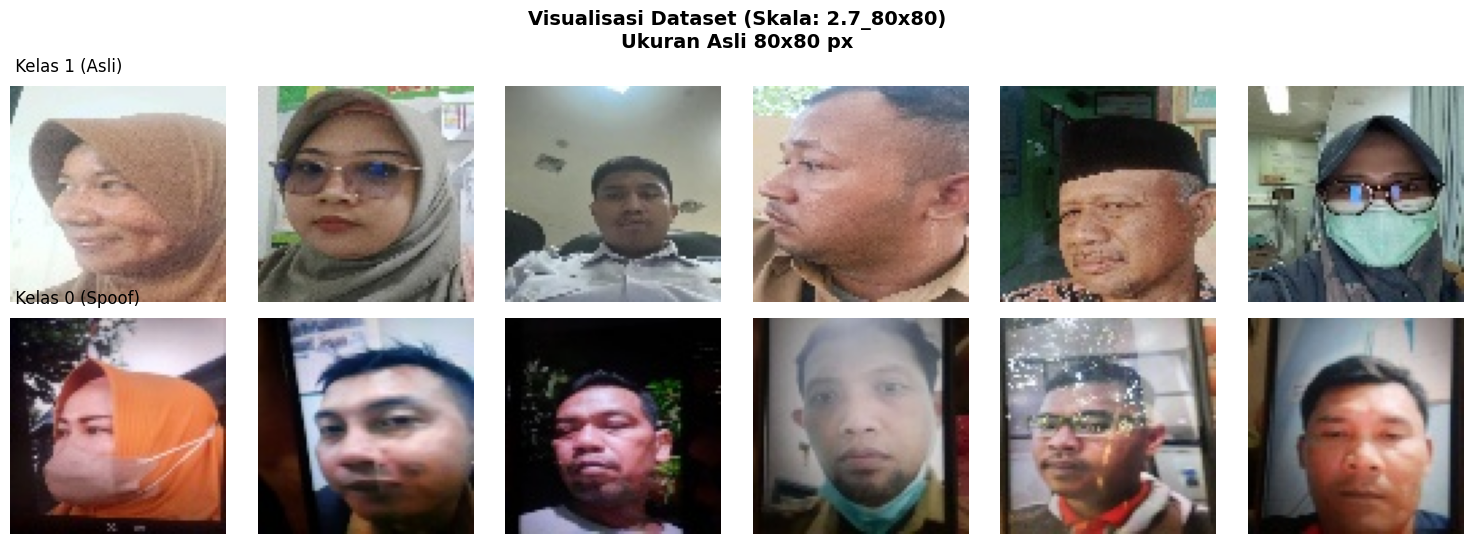

In [ ]:
import os
import glob
import random
import cv2
import matplotlib.pyplot as plt

def visualisasi_sampel_dataset(base_dir, skala='2.7_80x80', jumlah_sampel=5):
    """
    Mengambil dan menampilkan sampel acak gambar Asli dan Spoof.

    Args:
        base_dir (str)    : Direktori utama dataset (BASE_DATASET_DIR)
        skala (str)       : Pilihan skala ('1_80x80', '2.7_80x80', '4_80x80')
        jumlah_sampel (int): Jumlah gambar per baris
    """
    print(f"🔍 Mengambil sampel acak dari skala: {skala}")

    # Kumpulkan semua path gambar menggunakan glob
    # Direktori: base_dir / skala / label(1 atau 0) / kategori / file.jpg
    path_asli = glob.glob(os.path.join(base_dir, skala, '1', '**', '*.*'), recursive=True)
    path_spoof = glob.glob(os.path.join(base_dir, skala, '0', '**', '*.*'), recursive=True)

    # Pastikan ada cukup gambar untuk disampel
    if len(path_asli) < jumlah_sampel or len(path_spoof) < jumlah_sampel:
        print(" Gambar tidak cukup untuk disampel.")
        return

    # Ambil sampel acak
    sampel_asli = random.sample(path_asli, jumlah_sampel)
    sampel_spoof = random.sample(path_spoof, jumlah_sampel)

    # Siapkan kanvas Matplotlib (2 baris: atas Asli, bawah Spoof)
    fig, axes = plt.subplots(2, jumlah_sampel, figsize=(jumlah_sampel * 2.5, 5.5))
    fig.suptitle(f"Visualisasi Dataset (Skala: {skala})\nUkuran Asli 80x80 px", fontsize=14, fontweight='bold')

    # Plot Wajah Asli (Baris 0)
    for i, img_path in enumerate(sampel_asli):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR ke RGB agar warna normal di Matplotlib
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title(" Kelas 1 (Asli)", fontsize=12, pad=10, loc='left')

    # Plot Wajah Spoof (Baris 1)
    for i, img_path in enumerate(sampel_spoof):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title(" Kelas 0 (Spoof)", fontsize=12, pad=10, loc='left')

    plt.tight_layout()
    plt.show()

# Panggil fungsi visualisasi
# BASE_DATASET_DIR sudah didefinisikan di Cell 2.1
# Pilihan skala: '1_80x80', '2.7_80x80', atau '4_80x80'

visualisasi_sampel_dataset(BASE_DATASET_DIR, skala='2.7_80x80', jumlah_sampel=6)

## **Step 2.5: Split Dataset**

---
Tahap pembagian dataset menjadi 3 bagian:
*   Train (70%) → Data yang dipelajari model saat training
*   Val   (15%) → Data untuk memantau performa saat training berlangsung
*   Test  (15%) → Data yang tidak pernah dilihat model dan hanya dipakai untuk evaluasi akhir

In [ ]:
import os, random, collections

# Direktori Utama
BASE_DATASET_DIR = '/content/Silent-Face-Anti-Spoofing/datasets/rgb_image'

# Proporsi pembagian (total harus = 1.0)
TRAIN_RATIO = 0.70   # 70% → dipelajari model saat training
VAL_RATIO   = 0.15   # 15% → pantau performa saat training berlangsung
TEST_RATIO  = 0.15   # 15% → evaluasi akhir metrik (FAR/FRR)

# Definisi Skala (Skala pertama jadi Master)
SCALES = ['1_80x80', '2.7_80x80', '4_80x80']
MASTER_SCALE = SCALES[0]
LABELS = ['0', '1']

# Seed agar hasil split selalu sama
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

print(" Konfigurasi split siap:")
print(f"   Train : {TRAIN_RATIO*100:.0f}%")
print(f"   Val   : {VAL_RATIO*100:.0f}%")
print(f"   Test  : {TEST_RATIO*100:.0f}%")
print(f"   Seed  : {RANDOM_SEED}")

 Konfigurasi split siap:
   Train : 70%
   Val   : 15%
   Test  : 15%
   Seed  : 42


In [ ]:
def generate_split_txt_anti_leakage(base_dir: str):
    print("=" * 65)
    print("✂️  MEMULAI SPLIT DATASET (DUAL-FORMAT ANTI-LEAKAGE + SAFEGUARD)")
    print("=" * 65)

    lines = {'train': [], 'val': [], 'test': []}

    for label in LABELS:
        master_path = os.path.join(base_dir, MASTER_SCALE, label)
        if not os.path.exists(master_path):
            continue

        subfolders = [f for f in os.listdir(master_path) if os.path.isdir(os.path.join(master_path, f))]
        subfolders = subfolders if subfolders else ['']

        for kategori in subfolders:
            folder = os.path.join(master_path, kategori) if kategori else master_path
            semua_file = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png'))]

            if not semua_file:
                continue

            # 1. KELOMPOKKAN FOTO DENGAN LOGIKA GANDA (ASLI vs SPOOF)
            grup_subjek = collections.defaultdict(list)
            for f in semua_file:
                if label == '1':
                    subjek_id = f.rsplit('_', 1)[-1].rsplit('.', 1)[0]
                else:
                    parts = f.split('_')
                    if len(parts) >= 2 and len(parts[1]) >= 2:
                        subjek_id = f"{parts[0]}_{parts[1][:2]}"
                    else:
                        subjek_id = f.rsplit('.', 1)[0]

                kunci_grup = f"L{label}_{subjek_id}"
                grup_subjek[kunci_grup].append(f)

            # 2. PROSES UNDIAN ORANG/SESI
            daftar_subjek = list(grup_subjek.keys())
            random.shuffle(daftar_subjek)

            n_subjek = len(daftar_subjek)

            # ---------------------------------------------------------
            # 🌟 REVISI: LOGIKA DISTRIBUSI ANTI-KOSONG (SAFEGUARD)
            # ---------------------------------------------------------
            if n_subjek >= 3:
                # Paksa minimal 1 grup jika hasil perkalian rasionya 0 (misal 0.6 -> 1)
                n_val  = max(1, int(n_subjek * VAL_RATIO))
                n_test = max(1, int(n_subjek * TEST_RATIO))
                n_train = n_subjek - n_val - n_test

                # Jaga-jaga jika train malah habis (walau tidak mungkin terjadi di ratio 0.7)
                if n_train <= 0:
                    n_train, n_val, n_test = 1, 1, 1
            elif n_subjek == 2:
                n_train, n_val, n_test = 1, 1, 0
            else:
                n_train, n_val, n_test = 1, 0, 0
            # ---------------------------------------------------------

            subjek_train = set(daftar_subjek[:n_train])
            subjek_val   = set(daftar_subjek[n_train : n_train + n_val])

            # 3. DISTRIBUSIKAN FOTO SESUAI NASIB GRUPNYA
            bagian = {'train': [], 'val': [], 'test': []}
            for f in semua_file:
                if label == '1':
                    subjek_id = f.rsplit('_', 1)[-1].rsplit('.', 1)[0]
                else:
                    parts = f.split('_')
                    subjek_id = f"{parts[0]}_{parts[1][:2]}" if len(parts) >= 2 and len(parts[1]) >= 2 else f.rsplit('.', 1)[0]

                kunci_grup = f"L{label}_{subjek_id}"

                if kunci_grup in subjek_train:
                    bagian['train'].append(f)
                elif kunci_grup in subjek_val:
                    bagian['val'].append(f)
                else:
                    bagian['test'].append(f)

            # Tulis ke file TXT untuk semua skala
            for nama_split, daftar_file in bagian.items():
                for f in daftar_file:
                    for scale in SCALES:
                        rel_path = f"{scale}/{label}/{kategori}/{f}" if kategori else f"{scale}/{label}/{f}"
                        lines[nama_split].append(f"{rel_path} {label}\n")

            # Log Visual
            nama_label = "Asli " if label == '1' else "Spoof"
            nama_kat   = kategori if kategori else 'root'
            print(
                f"  ✅ {nama_label} | {nama_kat:<15} → "
                f"Sesi Unik: {n_subjek:<3} | "
                f"Foto: Train={len(bagian['train']):>3}, Val={len(bagian['val']):>3}, Test={len(bagian['test']):>3}"
            )

    # Acak hasil akhir
    for nama_split in lines:
        random.shuffle(lines[nama_split])
        txt_path = os.path.join(base_dir, f"{nama_split}_list.txt")
        with open(txt_path, 'w') as f:
            f.writelines(lines[nama_split])

    print("\n🚀 File TXT berhasil di-generate dengan keamanan Anti-Leakage maksimum!")

# Jalankan fungsi
generate_split_txt_anti_leakage(BASE_DATASET_DIR)

✂️  MEMULAI SPLIT DATASET (DUAL-FORMAT ANTI-LEAKAGE + SAFEGUARD)
  ✅ Spoof | kacamata        → Sesi Unik: 4   | Foto: Train= 39, Val= 16, Test= 28
  ✅ Spoof | low_resolution  → Sesi Unik: 4   | Foto: Train= 51, Val= 38, Test= 36
  ✅ Spoof | kombinasi_atribut → Sesi Unik: 4   | Foto: Train= 60, Val= 18, Test= 27
  ✅ Spoof | helm            → Sesi Unik: 4   | Foto: Train= 59, Val= 20, Test= 38
  ✅ Spoof | sudut_jarak     → Sesi Unik: 4   | Foto: Train= 26, Val= 15, Test= 12
  ✅ Spoof | normal          → Sesi Unik: 4   | Foto: Train= 92, Val= 35, Test= 35
  ✅ Spoof | low_light       → Sesi Unik: 4   | Foto: Train= 44, Val= 25, Test= 38
  ✅ Spoof | masker          → Sesi Unik: 7   | Foto: Train= 58, Val=  5, Test= 22
  ✅ Spoof | backlight       → Sesi Unik: 5   | Foto: Train= 77, Val= 19, Test= 21
  ✅ Asli  | kacamata        → Sesi Unik: 94  | Foto: Train= 66, Val= 14, Test= 14
  ✅ Asli  | low_resolution  → Sesi Unik: 142 | Foto: Train=100, Val= 21, Test= 21
  ✅ Asli  | kombinasi_atribut →

 Membaca daftar file dari: /content/Silent-Face-Anti-Spoofing/datasets/rgb_image/train_list.txt
 Total gambar (Skala 1_80x80) di train_list.txt: 1280


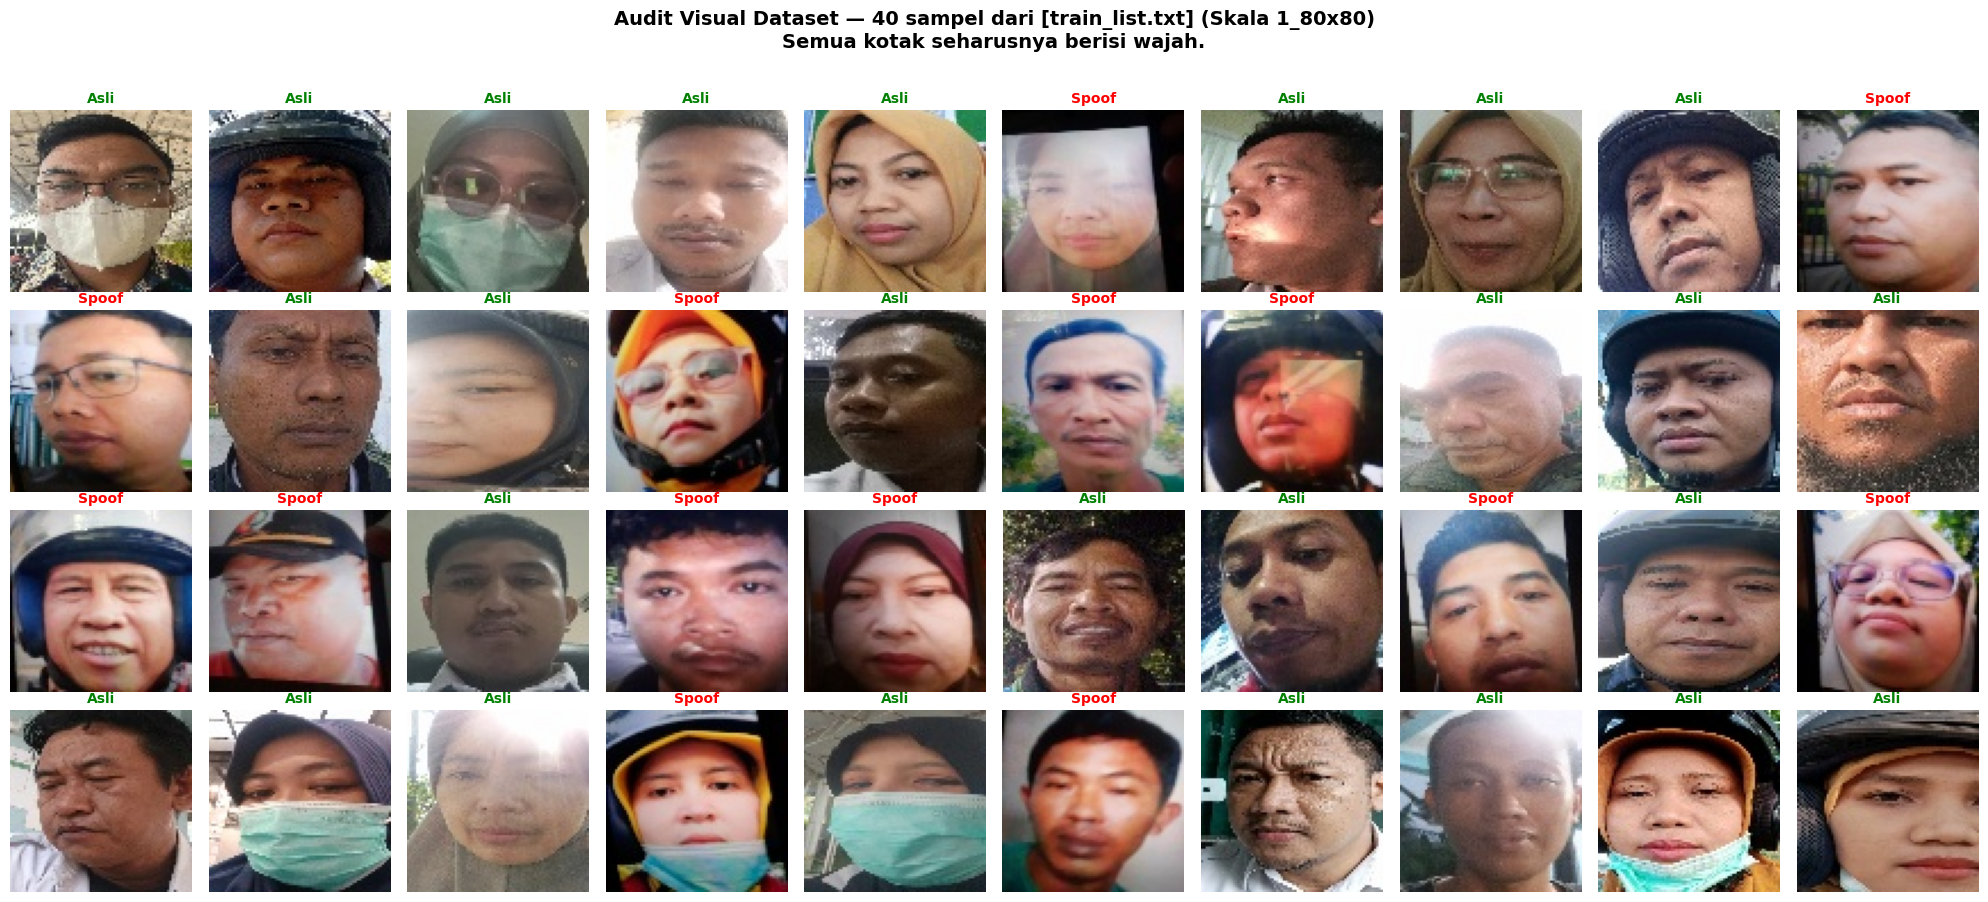


 Inspeksi selesai
   Jika semua kotak berisi wajah → Dataset Sempurna!
   Jika banyak gambar aneh → Ada masalah di tahap pemotongan (Step 2)


In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

def audit_kualitas_crop_txt(base_dir: str, list_file: str = 'train_list.txt', target_scale: str = '1_80x80', sampel: int = 50):
    """
    Tampilkan grid sampel gambar untuk inspeksi visual berdasarkan file .txt.
    Label hijau = Asli, merah = Spoof.

    Args:
        base_dir     : Folder root dataset (BASE_DATASET_DIR)
        list_file    : Nama file list (train_list.txt, val_list.txt, test_list.txt)
        target_scale : Skala yang ingin diaudit ('1_80x80', '2.7_80x80', '4_80x80')
        sampel       : Jumlah maksimal gambar yang ditampilkan
    """
    txt_path = os.path.join(base_dir, list_file)
    print(f" Membaca daftar file dari: {txt_path}")

    if not os.path.exists(txt_path):
        print(f" File tidak ditemukan: {txt_path}")
        return

    # ── Membaca isi TXT dan memfilter sesuai skala ──
    with open(txt_path, 'r') as f:
        semua_baris = f.readlines()

    # Format baris: "skala/label/kategori/foto.jpg label\n"
    baris_terfilter = [b.strip() for b in semua_baris if b.startswith(target_scale)]

    print(f" Total gambar (Skala {target_scale}) di {list_file}: {len(baris_terfilter)}")

    if not baris_terfilter:
        print(" Tidak ada gambar yang sesuai kriteria!")
        return

    # ── Ambil Sampel Acak ──
    n_sampel = min(sampel, len(baris_terfilter))
    sampel_baris = random.sample(baris_terfilter, n_sampel)

    cols = 10
    rows = (n_sampel + cols - 1) // cols

    # ── Plotting Grid ──
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 2.2))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, baris in enumerate(sampel_baris):
        # Memecah path gambar dan label target dari spasi paling kanan
        parts = baris.rsplit(' ', 1)
        img_rel_path = parts[0]
        label = parts[1]

        img_full_path = os.path.join(base_dir, img_rel_path)
        img = cv2.imread(img_full_path)

        if img is not None:
            axes_flat[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        teks_label = 'Asli' if label == '1' else 'Spoof'
        warna_label = 'green' if label == '1' else 'red'

        axes_flat[i].set_title(teks_label, color=warna_label, fontsize=10, fontweight='bold')
        axes_flat[i].axis('off')

    # Matikan kotak sisa jika sampel tidak kelipatan 10
    for j in range(n_sampel, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle(
        f'Audit Visual Dataset — {n_sampel} sampel dari [{list_file}] (Skala {target_scale})\n'
        'Semua kotak seharusnya berisi wajah.',
        fontweight='bold', fontsize=14, y=1.02
    )
    plt.tight_layout()
    plt.show()

    print("\n Inspeksi selesai")
    print("   Jika semua kotak berisi wajah → Dataset Sempurna!")
    print("   Jika banyak gambar aneh → Ada masalah di tahap pemotongan (Step 2)")

# ── Panggil Fungsi ──
# Anda bisa mengubah list_file ke 'val_list.txt' atau 'test_list.txt'
# Anda juga bisa mengubah target_scale ke '2.7_80x80' atau '4_80x80'
audit_kualitas_crop_txt(BASE_DATASET_DIR, list_file='train_list.txt', target_scale='1_80x80', sampel=40)

## **Step 2.7: Augmentation**

---
Memperbanyak variasi data training


In [ ]:
# PyTorch Dataset & On-The-Fly Augmentation
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

#  ── RESEP AUGMENTASI (TRANSFORMS) ─────────────────────
train_transform = transforms.Compose([
    transforms.Resize((80, 80)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((80, 80)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#  ── KELAS PEMBACA DATASET ─────────────────────────────
class FaceSpoofDataset(Dataset):
    def __init__(self, txt_path, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().rsplit(' ', 1)
                if len(parts) == 2:
                    self.image_paths.append(parts[0])
                    self.labels.append(int(parts[1]))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.base_dir, self.image_paths[idx])

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # Cetak error agar tidak menjadi "Silent Failure"
            print(f"\n PERINGATAN: Gagal memuat gambar {img_path} | Error: {e}")
            image = Image.new('RGB', (80, 80), (0, 0, 0))

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

#  ── INISIALISASI DATALOADER ───────────────────────────
BASE_DATASET_DIR = '/content/Silent-Face-Anti-Spoofing/datasets/rgb_image'
BATCH_SIZE = 64

print("⚙️ Membangun Dataset & DataLoader...")

train_dataset = FaceSpoofDataset(os.path.join(BASE_DATASET_DIR, 'train_list.txt'), BASE_DATASET_DIR, transform=train_transform)
val_dataset   = FaceSpoofDataset(os.path.join(BASE_DATASET_DIR, 'val_list.txt'), BASE_DATASET_DIR, transform=val_test_transform)
test_dataset  = FaceSpoofDataset(os.path.join(BASE_DATASET_DIR, 'test_list.txt'), BASE_DATASET_DIR, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(" DataLoader Siap Beroperasi!")
print(f"    Train Loader : {len(train_loader)} batch (Total: {len(train_dataset)} foto)")
print(f"    Val Loader   : {len(val_loader)} batch (Total: {len(val_dataset)} foto)")
print(f"    Test Loader  : {len(test_loader)} batch (Total: {len(test_dataset)} foto)")

⚙️ Membangun Dataset & DataLoader...
 DataLoader Siap Beroperasi!
    Train Loader : 60 batch (Total: 3840 foto)
    Val Loader   : 17 batch (Total: 1059 foto)
    Test Loader  : 20 batch (Total: 1257 foto)


## **Step 3.0: Model Training**

---

Melatih 3 model MiniFASNet secara berurutan,
masing-masing menggunakan skala crop yang berbeda.
*   Model 1 → Dilatih dengan data skala 1.0  (zoom dekat)
*   Model 2 → Dilatih dengan data skala 2.7  (zoom sedang)
*   Model 3 → Dilatih dengan data skala 4.0  (zoom jauh)

  
  

In [ ]:
import os
from tqdm import tqdm

BASE_DATASET_DIR = '/content/Silent-Face-Anti-Spoofing/datasets/rgb_image'

print("Membangun struktur folder fisik (via Symlink) untuk repo...")

for split_name in ['train', 'val', 'test']:
    txt_path = os.path.join(BASE_DATASET_DIR, f'{split_name}_list.txt')

    if not os.path.exists(txt_path):
        print(f" File {txt_path} tidak ditemukan, dilewati.")
        continue

    with open(txt_path, 'r') as f:
        lines = f.readlines()

    print(f"\n Menautkan {split_name} ({len(lines)} foto)...")

    for line in tqdm(lines, desc=f"  Proses {split_name}"):
        # Kita ambil path relatifnya saja (sebelum spasi terakhir)
        rel_path = line.strip().rsplit(' ', 1)[0]

        src_path = os.path.join(BASE_DATASET_DIR, rel_path)
        dest_path = os.path.join(BASE_DATASET_DIR, split_name, rel_path)

        # Proses pembuatan tautan (Symlink)
        if os.path.exists(src_path):
            os.makedirs(os.path.dirname(dest_path), exist_ok=True)
            # Cek dulu agar tidak error jika cell ini dijalankan 2 kali
            if not os.path.exists(dest_path):
                os.symlink(src_path, dest_path)

print("\n Struktur folder fisik Sempurna!")

Membangun struktur folder fisik (via Symlink) untuk repo...

 Menautkan train (3840 foto)...


  Proses train: 100%|██████████| 3840/3840 [00:00<00:00, 12203.69it/s]



 Menautkan val (1059 foto)...


  Proses val: 100%|██████████| 1059/1059 [00:00<00:00, 12469.80it/s]



 Menautkan test (1257 foto)...


  Proses test: 100%|██████████| 1257/1257 [00:00<00:00, 19120.19it/s]


 Struktur folder fisik Sempurna!


In [ ]:
%cd /content/Silent-Face-Anti-Spoofing
print("🚀 Memulai training Model 1 (skala 1_80x80)...")
!python train.py --patch_info 1_80x80

/content
🚀 Memulai training Model 1 (skala 1_80x80)...
🔍 Validasi dataset: ./datasets/rgb_image/train/1_80x80
   Class [0] Spoof:   506 foto
   Class [1] Asli :   774 foto
   ───────────────────────────────────
   Total          :  1280 foto
✅ Dataset valid, training siap dimulai

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
lr:  0.001
epochs:  150
milestones:  [60, 100, 130]
epoch 0 started
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:746: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.

In [ ]:
%cd /content/Silent-Face-Anti-Spoofing
print("🚀 Memulai training Model 2 (skala 2.7_80x80)...")
!python train.py --patch_info 2.7_80x80

/content
🚀 Memulai training Model 2 (skala 2.7_80x80)...
🔍 Validasi dataset: ./datasets/rgb_image/train/2.7_80x80
   Class [0] Spoof:   506 foto
   Class [1] Asli :   774 foto
   ───────────────────────────────────
   Total          :  1280 foto
✅ Dataset valid, training siap dimulai

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
lr:  0.001
epochs:  150
milestones:  [60, 100, 130]
epoch 0 started
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:746: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr

In [ ]:
%cd /content/Silent-Face-Anti-Spoofing
print("🚀 Memulai training Model 3 (skala 4_80x80)...")
!python train.py --patch_info 4_80x80

In [ ]:
# Memastikan ketiga file .pth tersimpan dengan benar
import glob, os

SKALA_LIST   = ['1_80x80', '2.7_80x80', '4_80x80']
LOG_BASE_DIR = '/content/Silent-Face-Anti-Spoofing/saved_logs'

print("=" * 55)
print(" VERIFIKASI MODEL HASIL TRAINING")
print("=" * 55)

semua_ada = True
for skala in SKALA_LIST:
    models = glob.glob(
        os.path.join(LOG_BASE_DIR, '**', f'*{skala}*.pth'),
        recursive=True
    )
    if models:
        model_terbaru = max(models, key=os.path.getctime)
        ukuran_mb     = os.path.getsize(model_terbaru) / (1024 * 1024)
        print(f"  ✅ {skala}")
        print(f"     File  : {os.path.basename(model_terbaru)}")
        print(f"     Ukuran: {ukuran_mb:.1f} MB")
    else:
        print(f"  ❌ {skala} — Model tidak ditemukan!")
        semua_ada = False

print("=" * 55)
if semua_ada:
    print("✅ Semua model tersimpan siap lanjut ke Step 4: Evaluasi")
else:
    print("⚠️  Ada model yang belum selesai jalankan ulang cell training yang gagal")

## **Step 4.0: Setup & Inisialisasi**
---

Persiapan lingkungan evaluasi. Mereload modul src/ agar perubahan terbaru
langsung aktif, menginisialisasi detektor wajah, dan memuat ketiga model
hasil training (.pth) secara otomatis dari folder saved_logs/.

In [ ]:
import os, cv2, sys, glob, random, importlib, warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

#  Pindah ke direktori repo
%cd /content/Silent-Face-Anti-Spoofing
sys.path.append('/content/Silent-Face-Anti-Spoofing')

#  Import dan Reload Modul Inti
import src.anti_spoof_predict
import src.utility
importlib.reload(src.anti_spoof_predict)
importlib.reload(src.utility)

from src.anti_spoof_predict import AntiSpoofPredict
from src.generate_patches import CropImage

#  Inisialisasi Mesin
predictor = AntiSpoofPredict(device_id=0)  # 0 = GPU
image_cropper = CropImage()
print(" Predictor dan image cropper siap")

#  Cari Model
SAVED_LOGS_DIR = '/content/Silent-Face-Anti-Spoofing/saved_logs'

def cari_model_terbaru(nama_skala: str) -> str:
    pattern = os.path.join(SAVED_LOGS_DIR, '**', f'*{nama_skala}*.pth')
    semua_pth = glob.glob(pattern, recursive=True)
    if not semua_pth:
        raise FileNotFoundError(f" Model '{nama_skala}' tidak ditemukan!")
    return max(semua_pth, key=os.path.getctime)

MODEL_PATHS = {
    1.0: cari_model_terbaru('1_80x80'),
    2.7: cari_model_terbaru('2.7_80x80'),
    4.0: cari_model_terbaru('4_80x80'),
}

print("\n Model ditemukan:")
for skala, path in MODEL_PATHS.items():
    ukuran_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"   Skala {skala}x -> {os.path.basename(path)} ({ukuran_mb:.1f} MB)")

## **Step 4.5: Quick Test**

---
Uji cepat model dengan 4 foto sampel acak (2 Asli + 2 Spoof) dari raw data.
Bertujuan memastikan pipeline prediksi berjalan tanpa error sebelum evaluasi
formal dijalankan ke seluruh test set.

In [ ]:
def cari_semua_gambar(folder: str) -> list:
    hasil = glob.glob(os.path.join(folder, '*.*')) + glob.glob(os.path.join(folder, '**', '*.*'), recursive=True)
    return list(set([p for p in hasil if p.lower().endswith(('.jpg', '.jpeg', '.png')) and os.path.isfile(p)]))

def prediksi_satu_gambar(img_path: str) -> dict:
    image = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if image is None: raise ValueError("Gagal membaca foto")

    h_img, w_img = image.shape[:2]

    # [L1] DETEKSI UTAMA (YUNET)
    bbox = predictor.get_bbox(image)

    is_yunet_failed = False
    if bbox is None or len(bbox) < 4:
        is_yunet_failed = True
    else:
        # Pengecekan jatuh ke full frame (YuNet gagal spesifik)
        x, y, w, h = map(int, bbox[:4])
        if x == 0 and y == 0 and w == w_img and h == h_img:
            is_yunet_failed = True

    # [L2] DETEKSI CADANGAN (SCRFD FALLBACK)
    if is_yunet_failed:
        faces = scrfd_app.get(image)
        if len(faces) == 0:
            raise ValueError("Wajah tidak terdeteksi oleh YuNet maupun SCRFD")

        # Konversi format InsightFace [x1,y1,x2,y2] ke format YuNet [x,y,w,h]
        box = faces[0].bbox.astype(int)
        x1, y1 = max(0, box[0]), max(0, box[1])
        x2, y2 = min(w_img, box[2]), min(h_img, box[3])
        bbox = (x1, y1, x2 - x1, y2 - y1)
    else:
        # Jika YuNet berhasil, pastikan tipe datanya murni integer
        bbox = (int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3]))

    # CROP DAN PREDIKSI KEASLIAN
    c1 = image_cropper.crop(image, bbox, 1.0, 80, 80, True)
    c27 = image_cropper.crop(image, bbox, 2.7, 80, 80, True)
    c4 = image_cropper.crop(image, bbox, 4.0, 80, 80, True)

    p1 = predictor.predict(c1, MODEL_PATHS[1.0])
    p27 = predictor.predict(c27, MODEL_PATHS[2.7])
    p4 = predictor.predict(c4, MODEL_PATHS[4.0])

    prob_asli = float(((p1 + p27 + p4) / 3.0)[0][1])

    # Memanggil THRESHOLD langsung dari memori Step 0
    label = 1 if prob_asli >= THRESHOLD else 0
    confidence = prob_asli * 100 if label == 1 else (1 - prob_asli) * 100

    return {
        'image': cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
        'bbox': bbox,
        'label': label,
        'teks_hasil': "ASLI (Live)" if label == 1 else "PALSU (Spoof)",
        'confidence': confidence,
        'warna': 'green' if label == 1 else 'red',
        'detektor_dipakai': 'SCRFD' if is_yunet_failed else 'YuNet'
    }

ASLI_DIR  = '/content/ml_pipeline/01_raw_data/class_1_asli'
SPOOF_DIR = '/content/ml_pipeline/01_raw_data/class_0_spoof'

asli_list, spoof_list = cari_semua_gambar(ASLI_DIR), cari_semua_gambar(SPOOF_DIR)

if not asli_list or not spoof_list:
    print("⚠️ Folder data mentah kosong. Lewati visualisasi tes.")
else:
    # Memilih sampel secara acak
    sampel = random.sample(asli_list, min(2, len(asli_list))) + random.sample(spoof_list, min(2, len(spoof_list)))
    fig, axes = plt.subplots(1, len(sampel), figsize=(5 * len(sampel), 6))
    if len(sampel) == 1: axes = [axes]

    for i, img_path in enumerate(sampel):
        # 1. BACA GAMBAR MENTAH DULUAN (Sebagai cadangan jika AI gagal)
        try:
            raw_img = cv2.imread(img_path)
            raw_img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB) if raw_img is not None else np.zeros((80,80,3), dtype=np.uint8)
        except Exception:
            raw_img_rgb = np.zeros((80,80,3), dtype=np.uint8)

        # 2. PROSES PREDIKSI
        try:
            hasil = prediksi_satu_gambar(img_path)
            vis_img = hasil['image'].copy()
            x, y, w, h = hasil['bbox']

            # Gambar kotak deteksi wajah
            cv2.rectangle(vis_img, (x, y), (x+w, y+h), (0, 255, 0) if hasil['label'] == 1 else (255, 0, 0), 3)

            axes[i].imshow(vis_img)
            axes[i].set_title(
                f"Hasil: {hasil['teks_hasil']}\nConf: {hasil['confidence']:.1f}%\n[{hasil['detektor_dipakai']}]",
                color=hasil['warna'],
                fontweight='bold',
                fontsize=11
            )
        except Exception as e:
            # 3. PENANGANAN ERROR (Tampilkan foto mentah + Pesan Jelas)
            axes[i].imshow(raw_img_rgb) # Tetap tampilkan fotonya

            error_str = str(e).replace("'", "")
            if error_str == "1.0":
                pesan_error = "Memori Model Hilang.\nJalankan ulang Step 4.0"
            else:
                pesan_error = f"{error_str[:35]}..."

            axes[i].set_title(f"❌ Error\n{pesan_error}", color='red', fontsize=10, fontweight='bold')

        axes[i].axis('off')

    plt.suptitle(f"Quick Test Ensemble (Threshold: {THRESHOLD})", fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()

## **Step 4.7: Evaluasi Formal**

---
Mengukur performa model secara kuantitatif menggunakan seluruh test set
data yang tidak pernah dilihat model selama training maupun validasi.
Menghasilkan classification report, AUC-ROC, confusion matrix, serta
dua metrik kritis untuk sistem absensi: FAR (foto palsu lolos) dan
FRR (foto asli ditolak), lengkap dengan verdict kelayakan deployment.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import os, glob, cv2
import matplotlib.pyplot as plt

TEST_DIR = '/content/Silent-Face-Anti-Spoofing/datasets/rgb_image/test'

def evaluasi_model_formal(test_dir: str):
    y_true, y_pred, y_prob = [], [], []
    error_count = 0

    for label_str in ['0', '1']:
        # Kita jadikan skala 1.0 sebagai acuan (anchor) pencarian file
        scale1_dir = os.path.join(test_dir, '1_80x80', label_str)
        if not os.path.exists(scale1_dir): continue

        paths_1 = [p for p in glob.glob(os.path.join(scale1_dir, '**', '*.*'), recursive=True) if p.lower().endswith(('.jpg', '.png'))]
        print(f"🔍 Memproses label {label_str} ({len(paths_1)} foto)...")

        for p1_path in paths_1:
            # Cari pasangan file di folder 2.7 dan 4.0 secara dinamis
            p27_path = p1_path.replace('1_80x80', '2.7_80x80')
            p4_path = p1_path.replace('1_80x80', '4_80x80')

            # Baca ketiga potongan gambar yang sudah siap (tanpa perlu deteksi/crop lagi)
            c1 = cv2.imread(p1_path)
            c27 = cv2.imread(p27_path)
            c4 = cv2.imread(p4_path)

            if c1 is None or c27 is None or c4 is None:
                error_count += 1
                continue

            try:
                # Langsung umpankan ke ONNX Model
                out1 = predictor.predict(c1, MODEL_PATHS[1.0])
                out27 = predictor.predict(c27, MODEL_PATHS[2.7])
                out4 = predictor.predict(c4, MODEL_PATHS[4.0])

                prob_asli = float(((out1 + out27 + out4) / 3.0)[0][1])

                y_true.append(int(label_str))
                y_pred.append(1 if prob_asli >= THRESHOLD else 0)
                y_prob.append(prob_asli)
            except Exception as e:
                error_count += 1

    if not y_true:
        print(" Tidak ada data yang berhasil dievaluasi.")
        return

    print("\n" + "=" * 50)
    print(" HASIL EVALUASI MODEL")
    print("=" * 50)

    if error_count > 0:
        print(f"⚠️ Melewati {error_count} file yang korup/hilang pasangannya.\n")

    print(classification_report(y_true, y_pred, target_names=['PALSU (Spoof)', 'ASLI (Live)'], labels=[0, 1]))

    if len(set(y_true)) > 1:
        print(f"🎯 AUC-ROC : {roc_auc_score(y_true, y_prob):.4f}")

    # Visualisasi Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, labels=[0, 1]), display_labels=['PALSU', 'ASLI'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
    plt.show()

    # Perhitungan Metrik FAR dan FRR
    n_spoof, n_asli = y_true.count(0), y_true.count(1)
    far = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1) / max(n_spoof, 1)
    frr = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0) / max(n_asli, 1)

    print("\n⚠️ METRIK KRITIS ABSENSI")
    print(f"  FAR (Foto palsu lolos)  : {far*100:.2f}%  (Target < 1%)")
    print(f"  FRR (Foto asli ditolak) : {frr*100:.2f}%  (Target < 5%)")

evaluasi_model_formal(TEST_DIR)

## **Step 4.9: Analisis Mendalam**

---
Membedah performa model lebih jauh melampaui angka akurasi keseluruhan.
Menampilkan akurasi per kategori kondisi (backlight, masker, helm, dll.),
distribusi confidence score untuk prediksi benar dan salah, serta daftar
lengkap foto yang salah diprediksi dan foto yang membuat model ragu-ragu
(confidence < 70%) sebagai panduan perbaikan dataset.

In [ ]:
def analisis_lengkap_dan_threshold(test_dir: str, model_paths: dict):
    hasil_kategori = {}
    distribusi = {'benar_asli': [], 'benar_spoof': [], 'salah_asli': [], 'salah_spoof': []}
    foto_salah, foto_ragu = [], []
    y_true, y_prob = [], []

    print("=" * 65)
    print("⚙️  MEMULAI ANALISIS MENDALAM & THRESHOLD OPTIMASI")
    print("=" * 65)

    for label_str in ['0', '1']:
        label_int = int(label_str)
        nama_kelas = "Asli" if label_str == '1' else "Spoof"
        scale1_dir = os.path.join(test_dir, '1_80x80', label_str) # Kita jadikan skala 1.0 sebagai acuan

        if not os.path.exists(scale1_dir): continue

        subfolders = [f for f in os.listdir(scale1_dir) if os.path.isdir(os.path.join(scale1_dir, f))]
        subfolders = subfolders if subfolders else ['']

        for kategori in subfolders:
            folder = os.path.join(scale1_dir, kategori) if kategori else scale1_dir
            nama_kat = kategori if kategori else 'lainnya'
            paths = [p for p in glob.glob(os.path.join(folder, '*.*')) if p.lower().endswith(('.jpg', '.png'))]

            if nama_kat not in hasil_kategori: hasil_kategori[nama_kat] = {'benar': 0, 'salah': 0}

            for p1_path in paths:
                # Langsung cari file 2.7 dan 4.0 tanpa deteksi/crop ulang
                p27_path = p1_path.replace('1_80x80', '2.7_80x80')
                p4_path = p1_path.replace('1_80x80', '4_80x80')

                c1 = cv2.imread(p1_path)
                c27 = cv2.imread(p27_path)
                c4 = cv2.imread(p4_path)

                # Lewati jika ada salah satu pasangan file yang korup/hilang
                if c1 is None or c27 is None or c4 is None: continue

                try:
                    # Langsung tembak ke model
                    p1 = predictor.predict(c1, model_paths[1.0])
                    p2 = predictor.predict(c27, model_paths[2.7])
                    p3 = predictor.predict(c4, model_paths[4.0])

                    prob_asli = float(((p1 + p2 + p3) / 3.0)[0][1])
                    pred_label = 1 if prob_asli >= THRESHOLD else 0
                    confidence = prob_asli * 100 if pred_label == 1 else (1 - prob_asli) * 100
                    benar = (pred_label == label_int)
                    nama_file = os.path.basename(p1_path)

                    y_true.append(label_int)
                    y_prob.append(prob_asli)

                    key = ('benar' if benar else 'salah') + '_' + ('asli' if label_int == 1 else 'spoof')
                    distribusi[key].append(confidence)
                    hasil_kategori[nama_kat]['benar' if benar else 'salah'] += 1

                    if not benar:
                        foto_salah.append({'file': nama_file, 'kategori': nama_kat, 'kelas': nama_kelas, 'prediksi': 'ASLI' if pred_label == 1 else 'PALSU', 'confidence': confidence})
                    if confidence < 70.0:
                        foto_ragu.append({'file': nama_file, 'kategori': nama_kat, 'kelas': nama_kelas, 'prediksi': 'ASLI' if pred_label == 1 else 'PALSU', 'confidence': confidence, 'benar': benar})
                except Exception:
                    continue

    if not y_true:
        return print(" Error: Tidak ada data yang berhasil dievaluasi. Periksa path dataset Anda.")

    # ── [1] Tabel Akurasi per Kategori ────────
    print("\n AKURASI PER KATEGORI")
    print(f"  {'Kategori':<20} {'Benar':>6} {'Salah':>6} {'Total':>6} {'Akurasi':>9}")
    akurasi_per_kat = {}
    for kat, data in sorted(hasil_kategori.items()):
        total = data['benar'] + data['salah']
        if total == 0: continue
        akurasi = data['benar'] / total * 100
        akurasi_per_kat[kat] = akurasi
        print(f"  {kat:<20} {data['benar']:>6} {data['salah']:>6} {total:>6} {akurasi:>8.1f}%" + (" ⚠️" if akurasi < 80 else ""))

    # ── [2] Grafik 4 Panel ────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Analisis Evaluasi Model Anti-Spoofing', fontweight='bold', fontsize=14)

    if akurasi_per_kat:
        names, vals = list(akurasi_per_kat.keys()), list(akurasi_per_kat.values())
        axes[0,0].bar(names, vals, color=['green' if v >= 80 else 'orange' for v in vals], edgecolor='white')
        axes[0,0].axhline(y=80, color='red', linestyle='--', alpha=0.7)
        axes[0,0].set_title('Akurasi per Kategori', fontweight='bold')
        axes[0,0].tick_params(axis='x', rotation=30)

    if distribusi['benar_asli'] or distribusi['benar_spoof']:
        axes[0,1].hist(distribusi['benar_asli'], bins=20, alpha=0.7, color='green', label=f"Asli ({len(distribusi['benar_asli'])})")
        axes[0,1].hist(distribusi['benar_spoof'], bins=20, alpha=0.7, color='blue', label=f"Spoof ({len(distribusi['benar_spoof'])})")
        axes[0,1].axvline(x=70, color='red', linestyle='--')
        axes[0,1].set_title('Confidence — Prediksi BENAR', fontweight='bold')
        axes[0,1].legend()

    if distribusi['salah_asli'] or distribusi['salah_spoof']:
        axes[1,0].hist(distribusi['salah_asli'], bins=10, alpha=0.7, color='orange', label=f"FRR ({len(distribusi['salah_asli'])})")
        axes[1,0].hist(distribusi['salah_spoof'], bins=10, alpha=0.7, color='red', label=f"FAR ({len(distribusi['salah_spoof'])})")
        axes[1,0].set_title('Confidence — Prediksi SALAH', fontweight='bold')
        axes[1,0].legend()
    else:
        axes[1,0].text(0.5, 0.5, '🎉 Tidak ada prediksi salah!', ha='center', va='center', fontsize=14, color='green')

    if hasil_kategori:
        names = [k for k, d in sorted(hasil_kategori.items()) if d['benar']+d['salah'] > 0]
        v_benar = [hasil_kategori[k]['benar'] for k in names]
        v_salah = [hasil_kategori[k]['salah'] for k in names]
        x = range(len(names))
        axes[1,1].bar(x, v_benar, label='Benar', color='steelblue')
        axes[1,1].bar(x, v_salah, bottom=v_benar, label='Salah', color='salmon')
        axes[1,1].set_title('Benar vs Salah per Kategori', fontweight='bold')
        axes[1,1].set_xticks(list(x))
        axes[1,1].set_xticklabels(names, rotation=30)
        axes[1,1].legend()

    plt.tight_layout()
    plt.show()

    # ── [3] Pencarian Threshold Optimal ───────
    print("\n" + "=" * 65)
    print("📈 ANALISIS THRESHOLD OPTIMAL (FAR vs FRR)")
    print("=" * 65)

    thresholds = [i / 100 for i in range(40, 91, 5)]
    hasil_threshold = []

    for t in thresholds:
        y_pred = [1 if p >= t else 0 for p in y_prob]
        n_spoof, n_asli = y_true.count(0), y_true.count(1)
        far = sum(1 for tr, pr in zip(y_true, y_pred) if tr == 0 and pr == 1) / max(n_spoof, 1)
        frr = sum(1 for tr, pr in zip(y_true, y_pred) if tr == 1 and pr == 0) / max(n_asli, 1)
        acc = sum(1 for tr, pr in zip(y_true, y_pred) if tr == pr) / max(len(y_true), 1)
        hasil_threshold.append({'threshold': t, 'far': far * 100, 'frr': frr * 100, 'akurasi': acc * 100})

    print(f"  {'Threshold':>10} {'FAR':>8} {'FRR':>8} {'Akurasi':>10}  Status")
    print(f"  {'─'*10} {'─'*8} {'─'*8} {'─'*10}  {'─'*12}")

    for h in hasil_threshold:
        status = "🟢 Ideal" if h['far'] < 1.0 and h['frr'] < 5.0 else ("🟡 FAR oke, FRR tinggi" if h['far'] < 1.0 else ("🟡 Kandidat" if h['far'] < 3.0 else ""))
        print(f"  {h['threshold']:>10.2f} {h['far']:>7.1f}% {h['frr']:>7.1f}% {h['akurasi']:>9.1f}%  {status}")

    kandidat = [h for h in hasil_threshold if h['far'] < 1.0]
    if kandidat:
        terbaik = min(kandidat, key=lambda x: x['frr'])
        print("\n💡 REKOMENDASI THRESHOLD:")
        print(f"   Nilai optimal : {terbaik['threshold']:.2f} (FAR: {terbaik['far']:.1f}%, FRR: {terbaik['frr']:.1f}%)")

# Eksekusi fungsi gabungan
analisis_lengkap_dan_threshold(TEST_DIR, MODEL_PATHS)

## **Step 5.0: Export ONNX**

---
Tahap export: Mengubah model PyTorch (.pth) menjadi format ONNX
agar bisa dijalankan di Rust via library ort (ONNX Runtime).

Kenapa ONNX?
→ PyTorch tidak bisa langsung dipakai di Rust
→ ONNX adalah format universal yang bisa dibaca
  oleh hampir semua bahasa pemrograman
→ Inference lebih cepat dari PyTorch
→ Tidak butuh GPU di server produksi

In [ ]:
# ONNX dan ONNX Runtime diinstall ulang untuk memastikan versi kompatibel.
# onnxruntime-gpu dipakai agar export bisa memanfaatkan GPU Colab.
!pip uninstall onnxruntime onnxruntime-gpu -y -q
!pip install onnx onnxscript onnxruntime-gpu -q

import os
import sys
import glob
import torch
import re
import numpy as np
import onnx
import onnxruntime as ort
from collections import OrderedDict

%cd /content/Silent-Face-Anti-Spoofing
sys.path.append('/content/Silent-Face-Anti-Spoofing')

from src.utility import parse_model_name
from src.model_lib.MiniFASNet import MiniFASNetV1SE, MiniFASNetV2

MODEL_DICT = {
    'MiniFASNetV1SE': MiniFASNetV1SE,
    'MiniFASNetV2'  : MiniFASNetV2
}

OUTPUT_DIR = '/content/Silent-Face-Anti-Spoofing/saved_models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Setup selesai")
print(f"   Output : {OUTPUT_DIR}")
print(f"   ONNX Runtime : {ort.__version__}")

In [ ]:
def cari_model_terbaru(nama_skala):
    """
    Mencari file .pth terbaru dari folder saved_logs.
    Mengambil yang terbaru karena itu hasil training paling akhir.
    """
    pattern   = f'/content/Silent-Face-Anti-Spoofing/saved_logs/**/*{nama_skala}*.pth'
    semua_pth = glob.glob(pattern, recursive=True)

    if not semua_pth:
        raise FileNotFoundError(
            f"Model '{nama_skala}' tidak ditemukan.\n"
            f"Pastikan Step 3 (Training) sudah selesai."
        )
    return max(semua_pth, key=os.path.getctime)


MODEL_PATHS = {
    '1_80x80'  : cari_model_terbaru('1_80x80'),
    '2.7_80x80': cari_model_terbaru('2.7_80x80'),
    '4_80x80'  : cari_model_terbaru('4_80x80'),
}

print("✅ Model ditemukan:")
for skala, path in MODEL_PATHS.items():
    ukuran_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"   {skala:<12} → {os.path.basename(path)} ({ukuran_mb:.1f} MB)")

In [ ]:
def export_ke_onnx(model_path, output_dir):
    """
    Mengubah 1 model PyTorch (.pth) ke format ONNX.

    Args:
        model_path : Path ke file .pth
        output_dir : Folder tujuan file .onnx

    Returns:
        str: Path ke file .onnx yang dihasilkan
    """
    device     = torch.device('cpu')
    model_name = os.path.basename(model_path)
    h, w, m_type, _ = parse_model_name(model_name)

    print(f"\n{'─'*50}")
    print(f"📦 {model_name}")
    print(f"   Arsitektur : {m_type} | Input: {h}×{w}")

    # Load weights
    model    = MODEL_DICT[m_type](conv6_kernel=(h // 16, w // 16)).to(device)
    sd       = torch.load(model_path, map_location=device)
    clean_sd = OrderedDict()

    for k, v in sd.items():
        if 'FTGenerator' in k:
            continue
        new_k = k.replace('module.', '').replace('model.', '')
        new_k = re.sub(r'conv_(\d+)\.(\d+)\.', r'conv_\1.model.\2.', new_k)
        new_k = new_k.replace('se_fc1', 'se_module.fc1')
        new_k = new_k.replace('se_bn1', 'se_module.bn1')
        new_k = new_k.replace('se_fc2', 'se_module.fc2')
        new_k = new_k.replace('se_bn2', 'se_module.bn2')
        clean_sd[new_k] = v

    model.load_state_dict(clean_sd, strict=False)
    model.eval()
    print(f"   ✅ Weights di-load")

    # Tentukan nama file output
    if '2.7' in model_name:
        nama_onnx = 'anti_spoofing_2.7_80x80.onnx'
    elif '4_80x80' in model_name:
        nama_onnx = 'anti_spoofing_4_80x80.onnx'
    else:
        nama_onnx = 'anti_spoofing_1_80x80.onnx'

    onnx_path   = os.path.join(output_dir, nama_onnx)
    dummy_input = torch.randn(1, 3, h, w, device=device)

# Export ke ONNX (Paksa Bobot Masuk ke Dalam File)
    torch.onnx.export(
        model, dummy_input, onnx_path,
        export_params      = True,        # WAJIB TRUE: Agar bobot tidak terpisah jadi .data
        input_names        = ['input'],
        output_names       = ['output'],
        dynamic_axes       = {
            'input' : {0: 'batch_size'},
            'output': {0: 'batch_size'}
        },
        opset_version      = 12,          # Gunakan opset 12 agar lebih stabil
        do_constant_folding = True
    )
    print(f"   ✅ Export → {nama_onnx}")

    # Validasi struktur ONNX
    onnx.checker.check_model(onnx.load(onnx_path))
    print(f"   ✅ Validasi ONNX passed")

    # Uji output PyTorch vs ONNX Runtime
    session    = ort.InferenceSession(onnx_path)
    ort_output = session.run(None, {'input': dummy_input.numpy()})[0]

    with torch.no_grad():
        pt_output = model(dummy_input).numpy()

    selisih = np.abs(pt_output - ort_output).max()
    status  = "✅" if selisih < 1e-4 else "⚠️ "
    print(f"   {status} Selisih PyTorch vs ONNX: {selisih:.2e}")
    print(f"   📦 Ukuran: {os.path.getsize(onnx_path)/(1024*1024):.2f} MB")

    return onnx_path

In [ ]:
import shutil

# Export semua model
print("=" * 50)
print("⚙️  EXPORT KE ONNX")
print("=" * 50)

onnx_paths = {}
for skala, pth_path in MODEL_PATHS.items():
    try:
        onnx_paths[skala] = export_ke_onnx(pth_path, OUTPUT_DIR)
    except Exception as e:
        print(f"❌ Gagal export {skala}: {e}")

# Ringkasan
print("\n" + "=" * 50)
print("📦 HASIL EXPORT")
print("=" * 50)
total_mb = 0
for skala, path in onnx_paths.items():
    if os.path.exists(path):
        mb        = os.path.getsize(path) / (1024 * 1024)
        total_mb += mb
        print(f"  ✅ {skala:<12} → {os.path.basename(path)} ({mb:.2f} MB)")
    else:
        print(f"  ❌ {skala:<12} → GAGAL")
print(f"  {'─'*40}")
print(f"  Total : {total_mb:.2f} MB")

# Simpan ke Google Drive
DRIVE_OUTPUT = '/content/drive/MyDrive/Anti_Spoofing_Models_ONNX'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)

print("📦 Menyikat dan menyatukan bobot external data...")
import onnx

# Melakukan loop otomatis berdasarkan jalur asli file (OUTPUT_DIR)
for skala, path in onnx_paths.items():
    if os.path.exists(path):
        print(f" 🔄 Memproses skala {skala} -> {os.path.basename(path)}")
        model_terpisah = onnx.load(path)
        onnx.save(model_terpisah, path) # Menimpa file lama & otomatis menyatukan .data ke dalam .onnx

print("✨ Selesai! Semua model sekarang sudah bersifat Standalone (Utuh).")

print(f"\n☁️  Menyimpan ke Google Drive...")

for skala, path in onnx_paths.items():
    if os.path.exists(path):
        shutil.copy(path, os.path.join(DRIVE_OUTPUT, os.path.basename(path)))
        print(f"   ✅ {os.path.basename(path)}")

# Simpan YuNet
yunet_src = '/content/Silent-Face-Anti-Spoofing/src/yunet.onnx'
if os.path.exists(yunet_src):
    shutil.copy(yunet_src, os.path.join(DRIVE_OUTPUT, 'yunet.onnx'))
    print(f"   ✅ yunet.onnx")

print(f"\n📁 Tersimpan di: {DRIVE_OUTPUT}")
print("\n" + "=" * 50)
print("🎉 PIPELINE SELESAI!")
print("=" * 50)
print("""
  File siap untuk Rust:
  ├── anti_spoofing_1_80x80.onnx    ← Skala 1.0 (tekstur kulit)
  ├── anti_spoofing_2.7_80x80.onnx  ← Skala 2.7 (proporsi kepala)
  ├── anti_spoofing_4_80x80.onnx    ← Skala 4.0 (konteks wajah)
  └── yunet.onnx                    ← Face detector
""")